# Confounders: is the Q5 climb / drop just a known factor in disguise?

`climb.ipynb` (long thesis) found heavily shorted stocks (Q5 days-to-cover) climb into the forced short-covering
deadline **D**; `drop.ipynb` (short thesis) found they fall after it. Before crediting forced covering, rule out four
ordinary explanations:

* **Market.** If TAIEX rallied during these windows (dividend season), everything rose, not just Q5.
* **Size.** Small caps earn different average returns, and Q5 may skew small.
* **Momentum.** Recent 12-month winners keep winning. If Q5 stocks were winners, the climb could be momentum.
* **Short-term reversal.** Last month's losers bounce and last month's winners give back. Q5 stocks may have been
  beaten down before D (a "climb" that is a rebound), and they certainly rose into D (a "drop" that is plain reversal).

**The regression** (one row per event *i* on deadline *t*):

$$r_{i,t} = \alpha + \gamma_{Q5}\,\mathbb 1[Q5] + \textstyle\sum_{g\ne Q1}\gamma_g \mathbb 1[g] + \beta_{mkt}\,\text{MKT}_t
+ \beta_{\beta}\,(\hat\beta_i\,\text{MKT}_t) + \beta_{size}\,\text{SIZE}_i + \beta_{mom}\,\text{MOM}_i + \beta_{rev}\,\text{REV}_i
+ \varepsilon_{i,t}$$

* $r_{i,t}$ = raw dividend-adjusted log return. **Long:** close of D−x to close of D. **Short:** close of D to close of
  D+x. x = 5 and 15 are the headline windows; x = 1…15 are all run.
* $\text{MKT}_t$ = TAIEX total-return log return over the same window; $\hat\beta_i\,\text{MKT}_t$ lets high-beta
  stocks move more with it ($\hat\beta_i$ = 250-day beta).
* **Characteristics are measured when the trade is entered** (long: close of D−15; short: close of D), so nothing uses
  future data. SIZE = log 20-day average turnover (no share counts in the panel, so turnover stands in for market cap);
  MOM = return from t−252 to t−21 (12-1 month); REV = return over the last 21 days. Each is z-scored, so the
  intercept is the return of a stock with average characteristics in a flat market.
* **What to read.** $\alpha_{Q5} = \alpha + \gamma_{Q5}$ is Q5's return left over after the factors (should be > 0 long,
  < 0 short). $\gamma_{Q5}$ = Q5 − Q1 is the part tied to short interest itself. A final spec adds **deadline-date
  fixed effects**, which absorb anything common to all stocks on that date (market, season, index flows); there only
  Q5 − Q1 is identified.
* **Standard errors** clustered two ways, by deadline date and by stock (events on the same date share shocks).

## 1. Data and events
**What this does.** Same panel and event construction as `climb.ipynb` / `drop.ipynb`: dividend-adjusted TWSE returns,
margin short balances, TAIEX total return, and the ban calendar; days-to-cover on D−17, quintiles within year,
stocks with no shorts as their own group.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
DATA = Path("data")
X_MAX = 15
SIG_LAG = 17
IS_END = pd.Timestamp("2023-12-31")
MIN_VAL20 = 2e7
HEAD = [("long", 15), ("long", 5), ("short", 5), ("short", 15)]

is_stock = lambda s: s.str.fullmatch(r"[1-9]\d{3}")
px = pd.read_csv(DATA / "prices.csv", dtype={"stock_id": str}, parse_dates=["date"])
px = px[is_stock(px.stock_id)].drop_duplicates(["date", "stock_id"]).sort_values(["stock_id", "date"])
exd = pd.read_csv(DATA / "exdiv.csv", dtype={"stock_id": str}, parse_dates=["date"])
exd = exd.dropna(subset=["close_before", "ref_price"]).drop_duplicates(["date", "stock_id"])
exd["adj"] = exd.ref_price / exd.close_before
px = px.merge(exd[["date", "stock_id", "adj"]], on=["date", "stock_id"], how="left")
px["adj"] = px["adj"].fillna(1.0)
px["close_ff"] = px.groupby("stock_id")["close"].ffill()
px["ret"] = px.close / (px.groupby("stock_id")["close_ff"].shift() * px.adj) - 1
px.loc[px.ret.abs() > 0.105, "ret"] = np.nan

idx = pd.read_csv(DATA / "index.csv", parse_dates=["date"]).drop_duplicates("date").sort_values("date").set_index("date")
cal = idx.index
mkt_tx = idx.taiex_tr.pct_change(fill_method=None)
mg = pd.read_csv(DATA / "margin.csv", dtype={"stock_id": str}, parse_dates=["date"])
mg = mg[is_stock(mg.stock_id)].drop_duplicates(["date", "stock_id"])
stocks = pd.Index(sorted(set(px.stock_id) & set(mg.stock_id)))
wide = lambda df, c: df.pivot(index="date", columns="stock_id", values=c).reindex(index=cal, columns=stocks)

R = wide(px, "ret")
SB = wide(mg, "short_bal")
ADV = (wide(px, "volume") / 1000).rolling(20, min_periods=10).mean()
VAL20 = wide(px, "value").rolling(20, min_periods=10).mean()
col = {s: i for i, s in enumerate(stocks)}
T, N = R.shape

def cumsum0(M):   # C[t+1] - C[a] = sum of M[a..t]
    return np.vstack([np.zeros((1, M.shape[1])), np.nancumsum(M, axis=0)])
LR = np.log1p(R.values)
C_RAW = cumsum0(LR)
C_TX = cumsum0(np.log1p(mkt_tx.fillna(0).values)[:, None])[:, 0]
TRADED = ~np.isnan(R.values)
print(f"{T} trading days {cal[0].date()} -> {cal[-1].date()}, {N} stocks")

2122 trading days 2018-01-02 -> 2026-09-23, 1111 stocks


In [2]:
ev = pd.read_csv(DATA / "suspension.csv", dtype={"stock_id": str}, parse_dates=["date", "end_date"]).drop_duplicates()
ev = ev[ev.stock_id.isin(stocks)].copy()
ev["D"] = cal.searchsorted(ev.date.values)
ev = ev[(ev.D >= SIG_LAG + 1) & (ev.D < T - 1)]
ev["j"] = ev.stock_id.map(col)
ev = ev.sort_values(["stock_id", "D"])
ev = ev[ev.groupby("stock_id").D.diff().fillna(99) >= 10].reset_index(drop=True)
ev["Ddate"] = cal[ev.D.values]
ev["year"] = ev.Ddate.dt.year

s_ = ev.D.values - SIG_LAG
J = ev.j.values
ev["sb_sig"] = SB.values[s_, J]
ev["dtc"] = SB.values[s_, J] / ADV.values[s_, J]
ev["val_sig"] = VAL20.values[s_, J]
ev = ev[np.isfinite(ev.sb_sig) & np.isfinite(ev.val_sig)].reset_index(drop=True)
quint = lambda s: np.ceil(s.rank(method="first", pct=True) * 5)
ev["grp"] = "no shorts"
has = (ev.sb_sig > 0) & np.isfinite(ev.dtc)
ev.loc[has, "grp"] = "Q" + ev[has].groupby("year").dtc.transform(quint).astype(int).astype(str)
GROUPS = ["no shorts", "Q1", "Q2", "Q3", "Q4", "Q5"]
D, J = ev.D.values, ev.j.values
print(f"{len(ev):,} events on {ev.Ddate.nunique()} deadline dates, {ev.stock_id.nunique()} stocks")

16,094 events on 1350 deadline dates, 1098 stocks


## 2. The confounders, measured at entry
**What this does.** For every event, computes SIZE, MOM, REV and 250-day market beta at the long entry (close of D−15)
and at the short entry (close of D), plus the market return over each window. REV for the short side is the last 21
days up to D, so it **contains the climb itself**; controlling for it is deliberately harsh on the short thesis (§5
also shows REV measured before the climb).

In [3]:
def ret_between(a, b):                  # log return from close of a to close of b, per event (NaN if not traded at both)
    ok = (a >= 0) & (b < T)
    a_, b_ = np.clip(a, 0, T - 1), np.clip(b, 0, T - 1)
    r = C_RAW[b_ + 1, J] - C_RAW[a_ + 1, J]
    return np.where(ok & TRADED[a_, J] & TRADED[b_, J], r, np.nan)

MKT_D = np.log1p(mkt_tx.values)
def beta_at(a, L=250, min_obs=120):
    out = np.full(len(a), np.nan)
    for i, (a_, j_) in enumerate(zip(a, J)):
        if a_ < L: continue
        r, m = LR[a_ - L + 1: a_ + 1, j_], MKT_D[a_ - L + 1: a_ + 1]
        k = np.isfinite(r) & np.isfinite(m)
        if k.sum() >= min_obs:
            out[i] = np.cov(r[k], m[k])[0, 1] / np.var(m[k], ddof=1)
    return out

def factors_at(a):
    return pd.DataFrame({"size": np.log(VAL20.values[a, J]),
                         "mom": ret_between(a - 252, a - 21),
                         "rev": ret_between(a - 21, a),
                         "beta": beta_at(a)})

FAC = {"long": factors_at(D - X_MAX), "short": factors_at(D)}
FAC["short"]["rev_pre"] = FAC["long"]["rev"]          # month before the climb (D-36 -> D-15)
for side, F in FAC.items():
    print(side, "factors available:", f"{F[['size', 'mom', 'rev', 'beta']].notna().all(axis=1).mean():.1%}")

long factors available: 87.7%
short factors available: 87.9%


In [4]:
def outcome(side, x):
    a, b = (D - x, D) if side == "long" else (D, D + x)
    y = ret_between(a, b) * 1e4
    ok = (a >= 0) & (b < T)
    mkt = np.where(ok, C_TX[np.clip(b, 0, T - 1) + 1] - C_TX[np.clip(a, 0, T - 1) + 1], np.nan) * 1e4
    return y, mkt

def make_df(side, x):
    y, mkt = outcome(side, x)
    F = FAC[side]
    d = pd.DataFrame({"y": y, "mkt": mkt, "grp": ev.grp, "D": D, "j": J, "year": ev.year, "val": ev.val_sig}).join(F)
    d = d.replace([np.inf, -np.inf], np.nan)
    d = d.dropna(subset=["y", "mkt", "size", "mom", "rev", "beta"]).copy()
    for c in ["size", "mom", "rev", "beta"] + (["rev_pre"] if "rev_pre" in d else []):
        d[c + "_z"] = (d[c] - d[c].mean()) / d[c].std()
    d["bmkt"] = d.beta * d.mkt            # beta x market: zero in a flat market
    return d

# how different is Q5 on these characteristics? (z-scores at entry)
prof = {side: make_df(side, 15).groupby("grp")[["size_z", "mom_z", "rev_z", "beta_z"]].mean().reindex(GROUPS)
        for side in ("long", "short")}
for side in prof:
    print(f"{side} entry: mean z-score by group"); print(prof[side].round(2).to_string(), "\n")

long entry: mean z-score by group
           size_z  mom_z  rev_z  beta_z
grp                                    
no shorts   -0.93  -0.23  -0.08   -0.62
Q1           0.22  -0.04  -0.02   -0.27
Q2           0.27   0.02  -0.02    0.04
Q3           0.43   0.11   0.04    0.32
Q4           0.55   0.22   0.14    0.57
Q5           0.39   0.15   0.02    0.57 

short entry: mean z-score by group
           size_z  mom_z  rev_z  beta_z
grp                                    
no shorts   -0.90  -0.23  -0.03   -0.62
Q1           0.19  -0.05  -0.00   -0.25
Q2           0.26   0.01   0.02    0.05
Q3           0.42   0.11   0.02    0.33
Q4           0.55   0.24   0.05    0.56
Q5           0.41   0.15  -0.01    0.57 



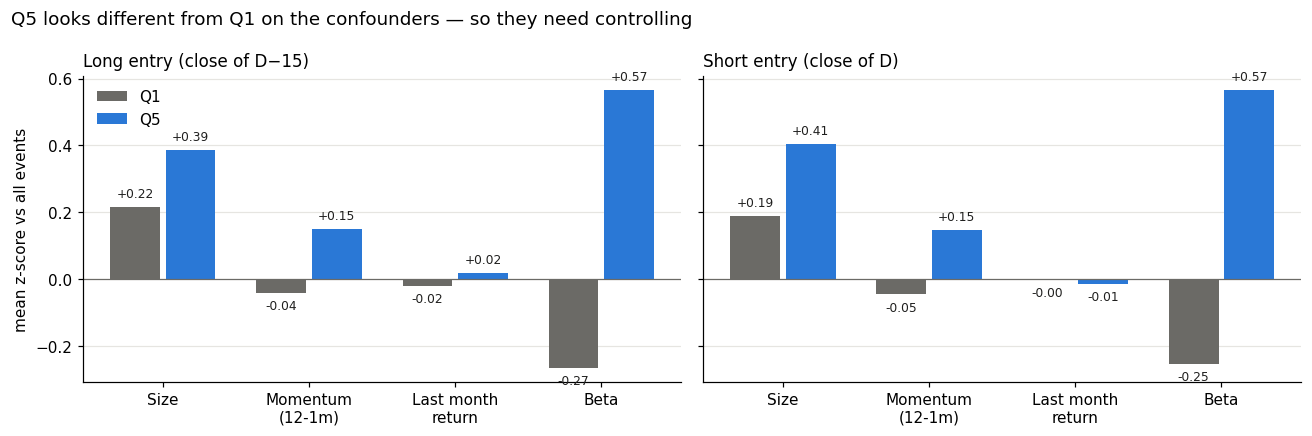

In [5]:
BLUE, ORANGE, AQUA, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#1f1f1e", "#6b6a66", "#e6e5e1"
def style(a, zero=True):
    a.grid(False); a.grid(axis="y", color=GRID, lw=.8); a.set_axisbelow(True)
    for sp in ("top", "right"): a.spines[sp].set_visible(False)
    if zero: a.axhline(0, color=MUTED, lw=.8)

FAC_LAB = {"size_z": "Size", "mom_z": "Momentum\n(12-1m)", "rev_z": "Last month\nreturn", "beta_z": "Beta"}
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for a, side, title in zip(axs, ("long", "short"), ("Long entry (close of D−15)", "Short entry (close of D)")):
    P = prof[side]; xs = np.arange(len(FAC_LAB)); w = 0.38
    for k, (g, c) in enumerate([("Q1", MUTED), ("Q5", BLUE)]):
        v = P.loc[g, list(FAC_LAB)].values
        a.bar(xs + (k - .5) * w, v, w - .04, color=c, label=g)
        for xi, vi in zip(xs, v):
            a.text(xi + (k - .5) * w, vi + (.02 if vi >= 0 else -.02), f"{vi:+.2f}", ha="center",
                   va="bottom" if vi >= 0 else "top", fontsize=8, color=INK)
    a.set_xticks(xs); a.set_xticklabels(FAC_LAB.values()); a.set_title(title, loc="left", fontsize=11)
    style(a)
axs[0].set_ylabel("mean z-score vs all events"); axs[0].legend(frameon=False)
fig.suptitle("Q5 looks different from Q1 on the confounders — so they need controlling", x=.01, ha="left", fontsize=12)
plt.tight_layout(); plt.show()

## 3. The regression ladder
**What this does.** Adds the controls one block at a time on the same sample: raw → + market (MKT and beta × MKT) →
+ size → + momentum → + reversal (the full model from the screenshot) → + deadline-date fixed effects. If $\alpha_{Q5}$
and Q5 − Q1 keep their sign and significance down the ladder, the effect is not those factors in disguise.

In [6]:
SPECS = [("raw", [], False),
         ("+ market", ["mkt", "bmkt"], False),
         ("+ size", ["mkt", "bmkt", "size_z"], False),
         ("+ momentum", ["mkt", "bmkt", "size_z", "mom_z"], False),
         ("+ reversal (full)", ["mkt", "bmkt", "size_z", "mom_z", "rev_z"], False),
         ("+ date FE", ["bmkt", "size_z", "mom_z", "rev_z"], True)]
FULL = SPECS[4][1]
DUMS = ["no shorts", "Q2", "Q3", "Q4", "Q5"]      # Q1 is the reference group

def fit(d, ctrl, fe=False):
    d = d.dropna(subset=ctrl)
    X = pd.get_dummies(d.grp).reindex(columns=DUMS, fill_value=0).astype(float)
    X = X.join(d[ctrl]); y = d.y
    if fe:
        y = y - y.groupby(d.D).transform("mean"); X = X - X.groupby(d.D).transform("mean")
    else:
        X = sm.add_constant(X)
    f = sm.OLS(y, X).fit(cov_type="cluster", cov_kwds={"groups": np.c_[d.D.values, d.j.values]})
    out = {"Q5−Q1": f.params["Q5"], "Q5−Q1 se": f.bse["Q5"], "Q5−Q1 t": f.tvalues["Q5"], "n": int(f.nobs)}
    if not fe:
        tt = f.t_test("const + Q5 = 0")
        a_, se_ = float(np.squeeze(tt.effect)), float(np.squeeze(tt.sd))
        out.update({"α_Q5": a_, "α_Q5 se": se_, "α_Q5 t": a_ / se_})
    return out, f

DF = {(s, x): make_df(s, x) for s in ("long", "short") for x in range(1, X_MAX + 1)}
ladder = {}
for side, x in HEAD:
    d = DF[side, x]
    ladder[side, x] = pd.DataFrame({nm: fit(d, c, fe)[0] for nm, c, fe in SPECS}).T
    lab = f"D−{x}→D" if side == "long" else f"D→D+{x}"
    print(f"\n{side.upper()} {lab}  (bp; want {'> 0' if side == 'long' else '< 0'})")
    print(ladder[side, x][["α_Q5", "α_Q5 t", "Q5−Q1", "Q5−Q1 t", "n"]].round(2).to_string())


LONG D−15→D  (bp; want > 0)
                    α_Q5  α_Q5 t  Q5−Q1  Q5−Q1 t        n
raw                98.14    1.55 -41.57    -0.95  14085.0
+ market            2.08    0.05 -53.56    -1.34  14085.0
+ size            -17.62   -0.41 -62.20    -1.55  14085.0
+ momentum        -15.08   -0.36 -74.11    -1.88  14085.0
+ reversal (full) -12.68   -0.30 -74.61    -1.90  14085.0
+ date FE            NaN     NaN -68.28    -1.80  14085.0

LONG D−5→D  (bp; want > 0)
                     α_Q5  α_Q5 t  Q5−Q1  Q5−Q1 t        n
raw                107.02    3.42  60.54     2.72  14073.0
+ market            43.49    1.94  29.60     1.54  14073.0
+ size              44.82    1.91  30.18     1.56  14073.0
+ momentum          45.30    1.96  25.94     1.36  14073.0
+ reversal (full)   46.06    2.00  25.74     1.36  14073.0
+ date FE             NaN     NaN  17.98     0.93  14073.0



SHORT D→D+5  (bp; want < 0)
                     α_Q5  α_Q5 t   Q5−Q1  Q5−Q1 t        n
raw                -67.38   -2.04  -86.16    -3.69  13926.0
+ market          -125.40   -6.01 -107.48    -5.61  13926.0
+ size            -113.25   -5.35 -101.17    -5.32  13926.0
+ momentum        -113.06   -5.34 -101.60    -5.35  13926.0
+ reversal (full) -113.19   -5.43 -101.69    -5.33  13926.0
+ date FE             NaN     NaN -109.41    -6.40  13926.0

SHORT D→D+15  (bp; want < 0)
                     α_Q5  α_Q5 t   Q5−Q1  Q5−Q1 t        n
raw               -188.51   -2.51 -179.90    -3.74  14084.0
+ market          -319.96   -8.07 -222.19    -7.34  14084.0
+ size            -297.69   -7.33 -210.53    -6.88  14084.0
+ momentum        -297.36   -7.33 -211.48    -6.92  14084.0
+ reversal (full) -298.81   -7.48 -212.45    -7.02  14084.0
+ date FE             NaN     NaN -212.72    -7.50  14084.0


In [7]:
# the full model's factor loadings, per 1 SD of each factor
for side, x in HEAD:
    d = DF[side, x]; _, f = fit(d, FULL)
    sd = {"mkt": d.mkt.std(), "bmkt": d.bmkt.std()}
    print(f"{side} x={x}: " + ", ".join(f"{c} {f.params[c] * sd.get(c, 1):+.0f}bp (t={f.tvalues[c]:.1f})" for c in FULL))

long x=15: mkt +248bp (t=5.5), bmkt +331bp (t=10.1), size_z -9bp (t=-0.7), mom_z +105bp (t=6.6), rev_z +46bp (t=1.8)
long x=5: mkt +105bp (t=3.0), bmkt +182bp (t=10.9), size_z -23bp (t=-3.0), mom_z +35bp (t=4.7), rev_z +13bp (t=1.1)
short x=5: mkt +27bp (t=0.9), bmkt +231bp (t=14.2), size_z -32bp (t=-4.0), mom_z +5bp (t=0.6), rev_z -1bp (t=-0.1)


short x=15: mkt +86bp (t=1.4), bmkt +447bp (t=15.0), size_z -57bp (t=-4.3), mom_z +11bp (t=0.6), rev_z -16bp (t=-0.7)


## 4. Robustness of the full model
**What this does.** Re-runs the date-FE model (the strictest) with returns winsorized at 1%/99%, on liquid names only
(≥ NT$20m/day, the tradeable set), on 2024+ only (after the in-sample cut used elsewhere), and — for the short side —
with reversal measured over the month *before* the climb (D−36→D−15) so the control no longer soaks up the climb.

In [8]:
FE_CTRL = SPECS[5][1]
def robust(side, x):
    d = DF[side, x]; rows = {}
    dw = d.copy(); lo, hi = d.y.quantile([.01, .99]); dw["y"] = d.y.clip(lo, hi)
    rows["winsorized 1/99"] = fit(dw, FE_CTRL, True)[0]
    rows["liquid ≥ NT$20m"] = fit(d[d.val >= MIN_VAL20], FE_CTRL, True)[0]
    rows["2024+ only"] = fit(d[d.year > IS_END.year], FE_CTRL, True)[0]
    rows["2018–2023 only"] = fit(d[d.year <= IS_END.year], FE_CTRL, True)[0]
    if side == "short":
        rows["REV before climb"] = fit(d, [c if c != "rev_z" else "rev_pre_z" for c in FE_CTRL], True)[0]
    return pd.DataFrame(rows).T
rob = {k: robust(*k) for k in HEAD}
for k, v in rob.items():
    print(f"\n{k[0]} x={k[1]} — Q5−Q1, date FE + all controls"); print(v[["Q5−Q1", "Q5−Q1 t", "n"]].round(2).to_string())


long x=15 — Q5−Q1, date FE + all controls
                 Q5−Q1  Q5−Q1 t        n
winsorized 1/99 -48.42    -1.39  14085.0
liquid ≥ NT$20m -89.29    -1.81   7961.0
2024+ only      -93.31    -1.27   5440.0
2018–2023 only  -54.61    -1.34   8645.0

long x=5 — Q5−Q1, date FE + all controls
                 Q5−Q1  Q5−Q1 t        n
winsorized 1/99  25.62     1.47  14073.0
liquid ≥ NT$20m   5.74     0.23   7961.0
2024+ only       34.06     1.01   5432.0
2018–2023 only    5.82     0.25   8641.0

short x=5 — Q5−Q1, date FE + all controls
                   Q5−Q1  Q5−Q1 t        n
winsorized 1/99  -109.94    -6.98  13926.0
liquid ≥ NT$20m  -116.48    -5.44   7884.0
2024+ only        -61.49    -2.12   5390.0
2018–2023 only   -131.54    -6.38   8536.0
REV before climb -108.72    -6.32  13875.0

short x=15 — Q5−Q1, date FE + all controls
                   Q5−Q1  Q5−Q1 t        n
winsorized 1/99  -207.09    -7.53  14084.0
liquid ≥ NT$20m  -236.13    -6.26   7955.0
2024+ only       -205.49    -4.

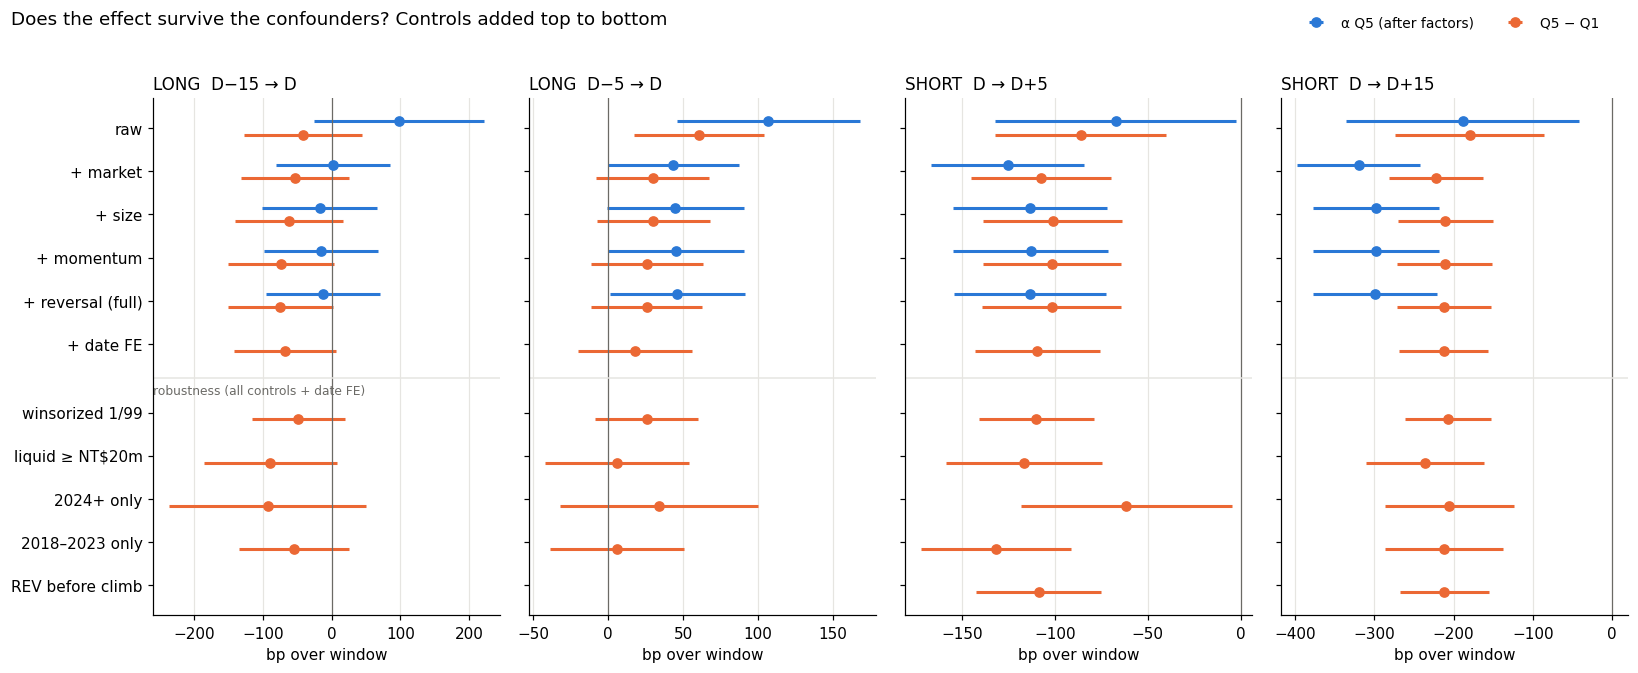

In [9]:
# Figure: the ladder. Blue = α_Q5 (Q5's own factor-adjusted return), orange = Q5 − Q1; 95% CI.
ROWS = [nm for nm, _, _ in SPECS] + list(rob["short", 15].index)
ys = np.arange(len(ROWS))[::-1].astype(float); ys[len(SPECS):] -= .6
fig, axs = plt.subplots(1, 4, figsize=(15, 6.2), sharey=True)
for a, (side, x) in zip(axs, HEAD):
    vals = pd.concat([ladder[side, x], rob[side, x]]).reindex(ROWS)
    for off, (m, se, c, lab) in [(.16, ("α_Q5", "α_Q5 se", BLUE, "α Q5 (after factors)")),
                                 (-.16, ("Q5−Q1", "Q5−Q1 se", ORANGE, "Q5 − Q1"))]:
        v, s = vals[m].values.astype(float), vals[se].values.astype(float)
        ok = np.isfinite(v)
        a.errorbar(v[ok], ys[ok] + off, xerr=1.96 * s[ok], fmt="o", ms=6, color=c, ecolor=c, elinewidth=2,
                   capsize=0, label=lab)
    a.axvline(0, color=MUTED, lw=.8)
    a.axhline(ys[len(SPECS)] + .8, color=GRID, lw=1)
    a.grid(False); a.grid(axis="x", color=GRID, lw=.8); a.set_axisbelow(True)
    a.set_title(("LONG  D−%d → D" % x) if side == "long" else ("SHORT  D → D+%d" % x), loc="left", fontsize=11)
    a.set_xlabel("bp over window")
axs[0].set_yticks(ys); axs[0].set_yticklabels(ROWS)
axs[0].annotate("robustness (all controls + date FE)", (0, ys[len(SPECS)] + .8), xycoords=("axes fraction", "data"),
                xytext=(0, -4), textcoords="offset points", fontsize=8, color=MUTED, va="top")
h_, l_ = axs[0].get_legend_handles_labels()
fig.legend(h_, l_, frameon=False, loc="upper right", bbox_to_anchor=(.98, .99), ncol=2, fontsize=9)
fig.suptitle("Does the effect survive the confounders? Controls added top to bottom", x=.01, ha="left", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, .96)); plt.show()

## 5. Every horizon, raw vs controlled
**What this does.** The same regressions for every window x = 1…15 (long: D−x→D; short: D→D+x). Gray = raw, blue =
full model (α_Q5) or full model + date FE (Q5 − Q1). Bands are 95% CIs. If blue tracks gray, the factors explain
little of it.

In [10]:
hz = []
for side in ("long", "short"):
    for x in range(1, X_MAX + 1):
        d = DF[side, x]
        raw, full, fe = fit(d, [])[0], fit(d, FULL)[0], fit(d, FE_CTRL, True)[0]
        hz.append({"side": side, "x": x, "α raw": raw["α_Q5"], "α raw se": raw["α_Q5 se"],
                   "α full": full["α_Q5"], "α full se": full["α_Q5 se"], "α full t": full["α_Q5 t"],
                   "c raw": raw["Q5−Q1"], "c raw se": raw["Q5−Q1 se"],
                   "c fe": fe["Q5−Q1"], "c fe se": fe["Q5−Q1 se"], "c fe t": fe["Q5−Q1 t"]})
hz = pd.DataFrame(hz)
print(hz.pivot(index="x", columns="side", values=["α full t", "c fe t"]).round(2).to_string())

     α full t       c fe t      
side     long short   long short
x                               
1        2.68 -5.64   1.30 -7.94
2        2.69 -6.19   1.22 -7.64
3        3.00 -5.52   1.68 -7.05
4        2.15 -5.28   1.28 -6.59
5        2.00 -5.43   0.93 -6.40
6        2.24 -4.98   1.02 -5.33
7        1.64 -5.58   0.45 -5.60
8        1.35 -5.72   0.16 -5.11
9        0.97 -6.13  -0.34 -4.99
10       0.55 -6.60  -0.84 -6.48
11       0.37 -6.51  -1.24 -7.06
12      -0.15 -5.77  -1.71 -6.71
13      -0.29 -5.30  -1.93 -6.58
14      -0.27 -6.15  -1.89 -6.61
15      -0.30 -7.48  -1.80 -7.50


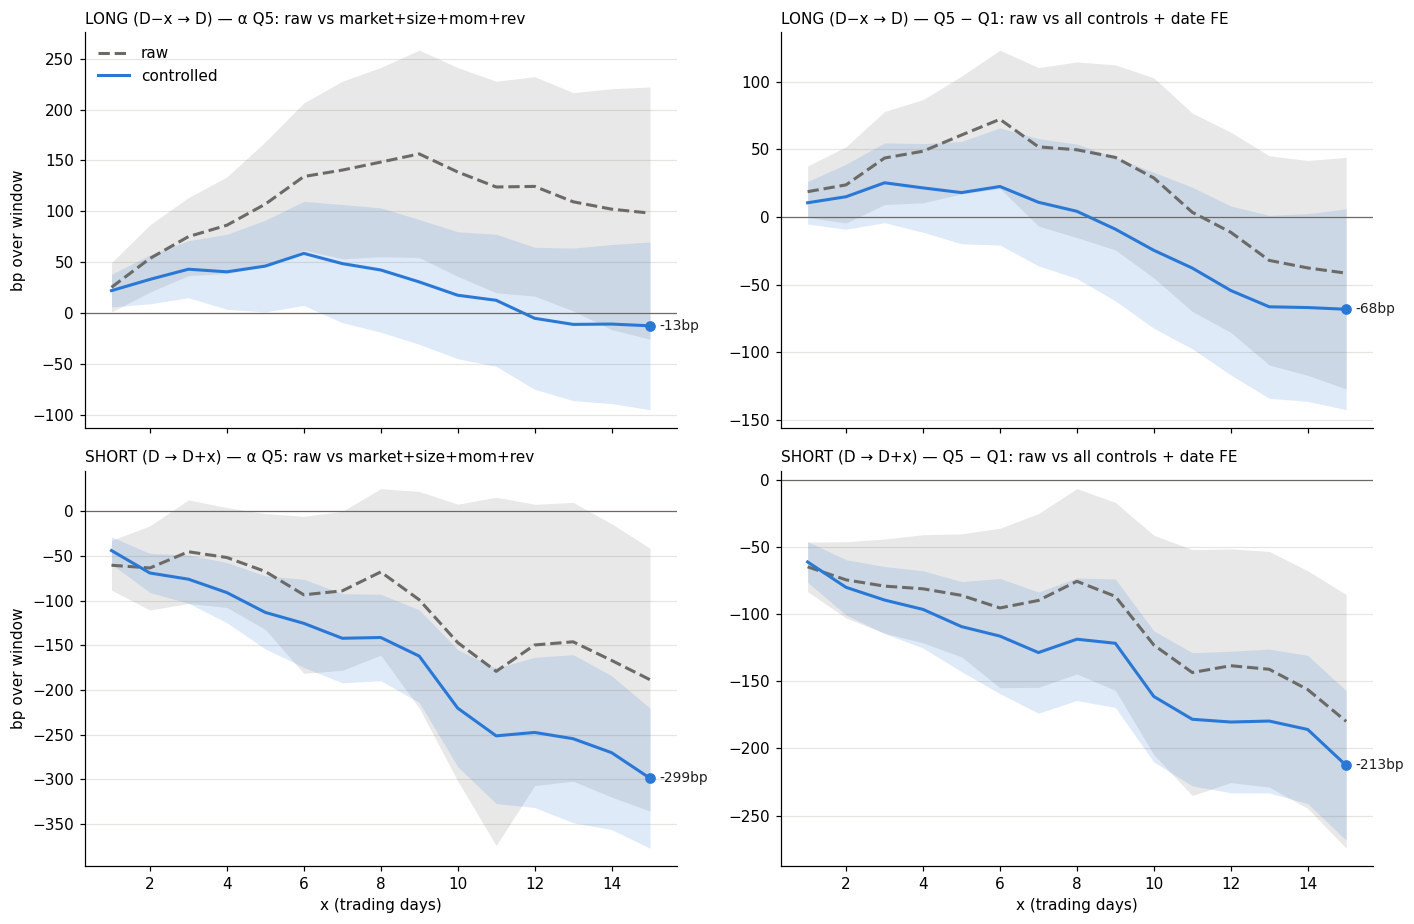

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True)
for r_, side in enumerate(("long", "short")):
    h = hz[hz.side == side]; x = h.x.values
    for c_, (raw, full, title) in enumerate([(("α raw", "α raw se"), ("α full", "α full se"),
                                              "α Q5: raw vs market+size+mom+rev"),
                                             (("c raw", "c raw se"), ("c fe", "c fe se"),
                                              "Q5 − Q1: raw vs all controls + date FE")]):
        a = axs[r_, c_]
        for (m, s), color, lab, ls in [(raw, MUTED, "raw", "--"), (full, BLUE, "controlled", "-")]:
            a.plot(x, h[m], color=color, lw=2, ls=ls, label=lab)
            a.fill_between(x, h[m] - 1.96 * h[s], h[m] + 1.96 * h[s], color=color, alpha=.15, lw=0)
        a.plot(x[-1], h[full[0]].values[-1], "o", color=BLUE, ms=6)
        a.annotate(f"{h[full[0]].values[-1]:+.0f}bp", (x[-1], h[full[0]].values[-1]), xytext=(6, 0),
                   textcoords="offset points", va="center", fontsize=9, color=INK)
        style(a)
        a.set_title(f"{'LONG (D−x → D)' if side == 'long' else 'SHORT (D → D+x)'} — {title}", loc="left", fontsize=10)
        if c_ == 0: a.set_ylabel("bp over window")
        if r_ == 1: a.set_xlabel("x (trading days)")
axs[0, 0].legend(frameon=False)
plt.tight_layout(); plt.show()

## 6. Non-parametric check: Q5 − Q1 within factor terciles
**What this does.** Regression controls assume the factor effects are linear. A double sort does not: split events into
terciles of each confounder (within year), and measure Q5 − Q1 *inside* each tercile (date-clustered). If the effect
is really small-cap, momentum or reversal, it should vanish in some tercile.

In [12]:
def within(d, fac):
    d = d[d.grp.isin(["Q1", "Q5"])].copy()
    d["terc"] = d.groupby("year")[fac].transform(lambda s: np.ceil(s.rank(method="first", pct=True) * 3))
    out = []
    for t_ in (1, 2, 3):
        e = d[d.terc == t_]
        X = sm.add_constant((e.grp == "Q5").astype(float).rename("Q5"))
        f = sm.OLS(e.y, X).fit(cov_type="cluster", cov_kwds={"groups": e.D.values})
        out.append((f.params["Q5"], f.bse["Q5"], f.tvalues["Q5"], len(e)))
    return out

TERC = {"size": ("small", "mid", "large"), "mom": ("losers", "mid", "winners"), "rev": ("fell", "flat", "rose")}
ds = {(side, x, fac): within(DF[side, x], fac) for side, x in HEAD for fac in TERC}
rows = [{"side": s, "x": x, "factor": f, "tercile": TERC[f][i], "Q5−Q1": v[0], "t": v[2], "n": v[3]}
        for (s, x, f), vs in ds.items() for i, v in enumerate(vs)]
order = pd.MultiIndex.from_tuples([(f, t_) for f in TERC for t_ in TERC[f]])
print(pd.DataFrame(rows).pivot_table(index=["factor", "tercile"], columns=["side", "x"], values="t").reindex(order).round(2).to_string())

side          long       short      
x               5     15    5     15
size small    0.84 -1.53 -2.82 -3.28
     mid      2.73 -0.10 -1.79 -2.80
     large    1.36 -0.61 -1.87 -1.61
mom  losers   2.35 -0.35 -2.34 -2.61
     mid      0.67 -1.04 -2.67 -3.47
     winners  1.80 -0.57 -2.10 -1.50
rev  fell     0.27 -2.34 -2.15 -2.48
     flat     2.57 -0.93 -2.98 -3.83
     rose     2.09  1.13 -2.39 -2.49


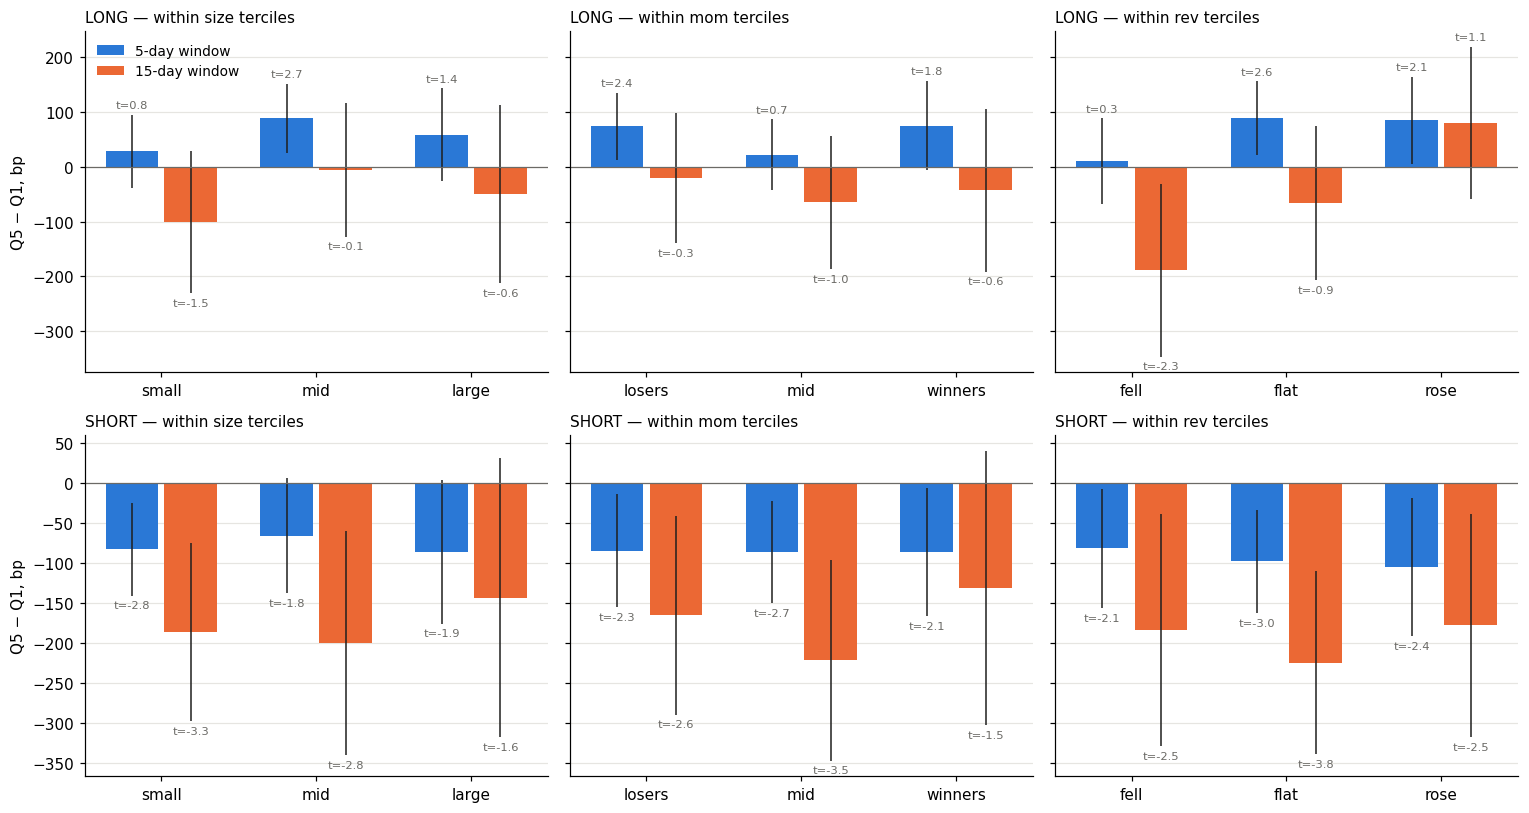

In [13]:
fig, axs = plt.subplots(2, 3, figsize=(14, 7.5), sharey="row")
for r_, side in enumerate(("long", "short")):
    for c_, fac in enumerate(TERC):
        a = axs[r_, c_]; xs = np.arange(3); w = .38
        for k, (x, color) in enumerate([(5, BLUE), (15, ORANGE)]):
            v = np.array(ds[side, x, fac])
            pos = xs + (k - .5) * w
            a.bar(pos, v[:, 0], w - .04, color=color, label=f"{x}-day window")
            a.errorbar(pos, v[:, 0], yerr=1.96 * v[:, 1], fmt="none", ecolor=INK, elinewidth=1, capsize=0)
            for p, (m_, se_, t_, _) in zip(pos, v):
                end = m_ + np.sign(m_) * 1.96 * se_
                a.annotate(f"t={t_:.1f}", (p, end), xytext=(0, 3 if m_ >= 0 else -3), textcoords="offset points",
                           ha="center", va="bottom" if m_ >= 0 else "top", fontsize=7.5, color=MUTED)
        a.set_xticks(xs); a.set_xticklabels(TERC[fac]); style(a)
        a.set_title(f"{side.upper()} — within {fac} terciles", loc="left", fontsize=10)
        if c_ == 0: a.set_ylabel("Q5 − Q1, bp")
axs[0, 0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 7. Year by year, fully controlled
**What this does.** The strictest model (all controls + date FE) fitted separately in each year: Q5 − Q1 with 95% CI.

side  long       short      
x       5     15    5     15
year                        
2019 -0.62 -0.37 -3.13 -2.36
2020  0.52 -1.17 -2.20 -0.07
2021  0.14 -0.68 -2.28 -3.44
2022  1.09 -0.14 -4.12 -3.42
2023 -0.08 -1.08 -3.53 -4.20
2024  0.79 -0.41 -1.52 -3.28
2025  0.80 -0.65 -1.28 -3.16
2026  0.38 -0.68 -1.10 -2.67


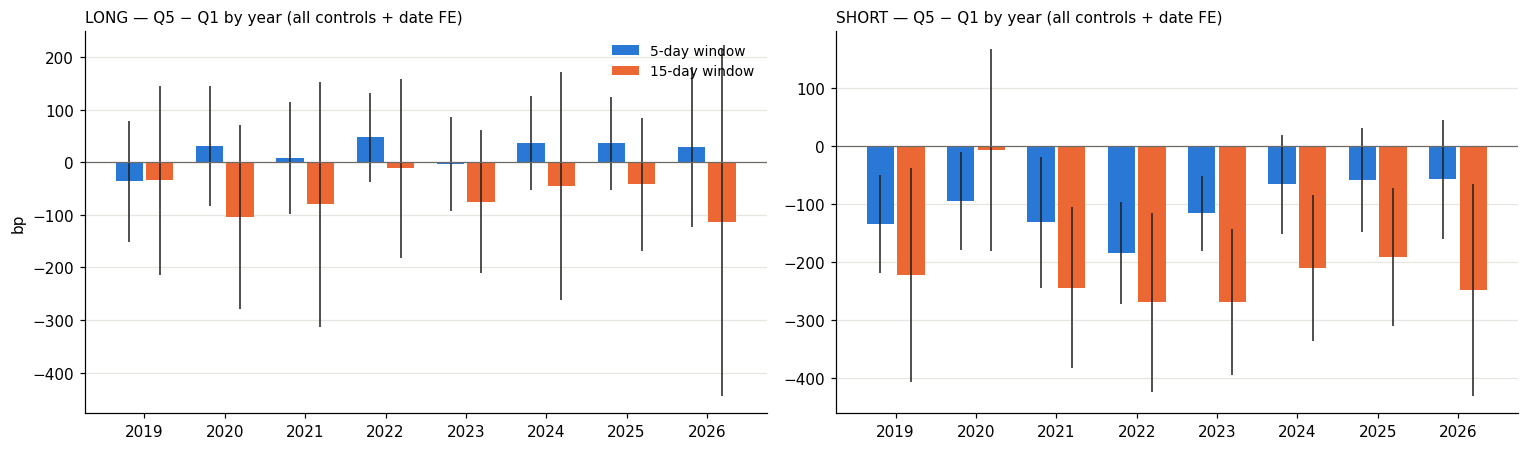

In [14]:
yrs = sorted(ev.year.unique())
by_year = []
for side, x in HEAD:
    d = DF[side, x]
    for y_ in yrs:
        e = d[d.year == y_]
        if (e.grp == "Q5").sum() < 30: continue
        o = fit(e, FE_CTRL, True)[0]
        by_year.append({"side": side, "x": x, "year": y_, "Q5−Q1": o["Q5−Q1"], "se": o["Q5−Q1 se"], "t": o["Q5−Q1 t"]})
by_year = pd.DataFrame(by_year)
print(by_year.pivot_table(index="year", columns=["side", "x"], values="t").round(2).to_string())

fig, axs = plt.subplots(1, 2, figsize=(14, 4.2))
for a, side in zip(axs, ("long", "short")):
    for k, (x, color) in enumerate([(5, BLUE), (15, ORANGE)]):
        b = by_year[(by_year.side == side) & (by_year.x == x)]
        pos = b.year.values + (k - .5) * .38
        a.bar(pos, b["Q5−Q1"], .34, color=color, label=f"{x}-day window")
        a.errorbar(pos, b["Q5−Q1"], yerr=1.96 * b.se, fmt="none", ecolor=INK, elinewidth=1)
    a.set_xticks(sorted(by_year.year.unique())); style(a)
    a.set_title(f"{side.upper()} — Q5 − Q1 by year (all controls + date FE)", loc="left", fontsize=10)
axs[0].set_ylabel("bp"); axs[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 8. Conclusion

| question | long (climb into D) | short (drop after D) |
|---|---|---|
| How does Q5 differ on the confounders? | Higher beta (+0.57 SD vs −0.27 for Q1), larger, mild 12-month winners. Last-month return ≈ average. | Same, and last-month return ≈ average even though it includes the climb. |
| Raw effect | α_Q5 D−5→D +107bp (t = 3.4); Q5 − Q1 +61bp (t = 2.7). 15 days: not significant. | Q5 − Q1 −86bp D→D+5 (t = −3.7), −180bp D→D+15 (t = −3.7). |
| After market (MKT + β×MKT) | **Most of it goes.** α_Q5 5-day +43bp (t = 1.9); Q5 − Q1 +30bp (t = 1.5). High-beta Q5 rides a rising season. | **Gets bigger.** Q5 − Q1 −107 / −222bp (t = −5.6 / −7.3): high beta was *hiding* part of the drop. |
| After size, momentum, reversal | Barely changes anything further (α_Q5 5-day +46bp, t = 2.0). | Barely changes anything further (−102 / −212bp, t = −5.3 / −7.0). |
| Strictest (all + date FE) | Q5 − Q1 **not significant at any horizon** (best t = 1.7 at x = 3; 15-day −68bp, t = −1.8). α_Q5 survives only for the last 1–3 days (+22–43bp, t = 2.7–3.0). | Q5 − Q1 **−109bp (t = −6.4) at 5 days, −213bp (t = −7.5) at 15 days**, significant at every x = 1…15 (t ≤ −5). |
| Robustness | Nothing significant: winsorized, liquid-only, 2018–23, 2024+. | Holds winsorized, liquid-only, both halves (2024+ 5-day weaker, t = −2.1; 15-day t = −4.9), and with REV measured before the climb. |
| Double sorts (non-linear control, no beta control) | 5-day positive in all 9 terciles but significant in only 4; 15-day ≈ 0 or negative. | Negative in all 9 factor terciles, significant in 7 of 9 at 15 days. |
| By year | No consistent sign. | Negative in all 8 years (2019–26) at 15 days; only 2020 is ≈ 0. |

**Long thesis: does not survive.** Most of the Q5 climb into D is market beta: Q5 stocks are high-beta and the deadline
windows (AGM / dividend season) are rising markets. Once β × market is controlled, what remains is a small +20–45bp
residual in the last 1–3 days that is not distinguishable from Q1 once deadline-date fixed effects are added. This is
harsher than `climb.ipynb`'s "survives momentum/size controls (t = 2.1)", which was measured against the equal-weighted
market and did not adjust for beta.

**Short thesis: survives, and gets stronger.** After market, beta, size, momentum and reversal, heavily shorted stocks
still fall ~1.1% in the week after D and ~2.1–3.0% over three weeks relative to comparable Q1 stocks (t = −6 to −7.5).
It is not reversal of the climb (the effect is unchanged whether REV includes the climb or not, and holds in every
reversal tercile), not size (holds in large caps), and not momentum.

**Caveats.** SIZE is turnover, not market cap (no share counts in the panel). MOM needs a year of history, so 2018
deadlines drop out (~12% of events). β is a 250-day OLS estimate. Returns are log, raw, dividend-adjusted.